In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

load the images

In [2]:
# 'object.jpg' is the image of the object you want to find
# 'scene.jpg' is the image where you want to locate the object
img_object = cv2.imread('images/object.jpg', cv2.IMREAD_GRAYSCALE)
img_scene = cv2.imread('images/scene.jpg', cv2.IMREAD_GRAYSCALE)

# Check if images loaded properly
if img_object is None or img_scene is None:
    print("Error loading images!")
    exit()

initialize detector

In [3]:
# detector = cv2.ORB_create(nfeatures=1000)

detector = cv2.SIFT_create()

find keypoints and descriptors

In [4]:
keypoints_obj, descriptors_obj = detector.detectAndCompute(img_object, None)
keypoints_scene, descriptors_scene = detector.detectAndCompute(img_scene, None)

create matcher

In [5]:
# matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)

FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
search_params = dict(checks=50)
matcher = cv2.FlannBasedMatcher(index_params, search_params)

match descriptors using KNN

In [6]:
matches = matcher.knnMatch(descriptors_obj, descriptors_scene, k=2)

apply Lowe's ratio test to filter good matches

In [7]:
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

draw matches for visualization

In [8]:
matched_img = cv2.drawMatches(
    img_object, keypoints_obj, img_scene, keypoints_scene, good_matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

minimum number of good matches required

In [9]:
MIN_MATCH_COUNT = 10

compute match quality (confidence)

In [10]:
match_ratio = len(good_matches) / len(matches) if len(matches) > 0 else 0
confidence = min(match_ratio * 100 * (len(good_matches) / (MIN_MATCH_COUNT + 5)), 100)

print(f"🔍 Total Matches: {len(matches)}")
print(f"✅ Good Matches: {len(good_matches)}")
print(f"📊 Confidence: {confidence:.2f}%")

🔍 Total Matches: 1776
✅ Good Matches: 357
📊 Confidence: 100.00%


initialize recognition flag

In [11]:
object_recognized = False

In [12]:
# Proceed only if enough matches
if len(good_matches) >= MIN_MATCH_COUNT:
    src_pts = np.float32([keypoints_obj[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoints_scene[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

    # Compute homography
    H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

    if H is not None:
        object_recognized = True
        h, w = img_object.shape
        # Define corner points of the object
        pts = np.float32([[0, 0], [0, h], [w, h], [w, 0]]).reshape(-1, 1, 2)
        # Map the object corners to the scene using Homography
        dst = cv2.perspectiveTransform(pts, H)

        img_scene_color = cv2.cvtColor(img_scene, cv2.COLOR_GRAY2BGR)
        cv2.polylines(img_scene_color, [np.int32(dst)], True, (0, 255, 0), 3, cv2.LINE_AA)
        cv2.putText(img_scene_color, "Object Recognized", (30, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2, cv2.LINE_AA)
    else:
        print("Homography could not be computed.")
else:
    print(f"Not enough good matches found ({len(good_matches)}/{MIN_MATCH_COUNT})")

final decision output

In [13]:
if object_recognized and confidence > 20:
    print("✅ FINAL DECISION: OBJECT RECOGNIZED")
else:
    print("❌ FINAL DECISION: OBJECT NOT RECOGNIZED")

✅ FINAL DECISION: OBJECT RECOGNIZED


In [ ]:
matched_img = cv2.drawMatches(
    img_object, keypoints_obj, img_scene, keypoints_scene,
    good_matches, None, flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

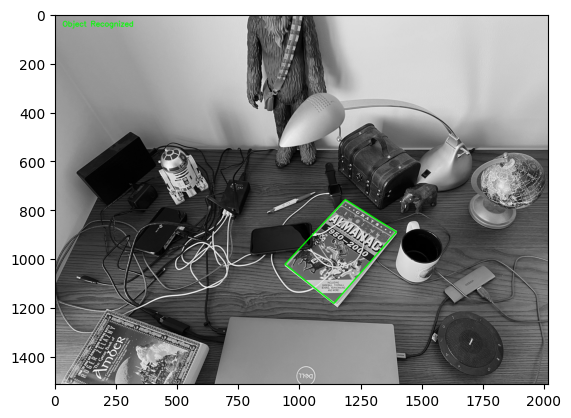

In [15]:
plt.imshow(matched_img)
if object_recognized:
    plt.imshow(img_scene_color)